File to visualize the label and graph

In [14]:
from pathlib import Path
import nibabel as nib
import json
import matplotlib.pyplot as plt
from data.visualizations import visualize_3d_matrices
import pprint
import numpy as np

In [15]:
label_graph_folder = Path("label_graph/")
graph_fp = label_graph_folder / "00328c.graph.json"
label_fp = label_graph_folder / "00328c.label.nii.gz"

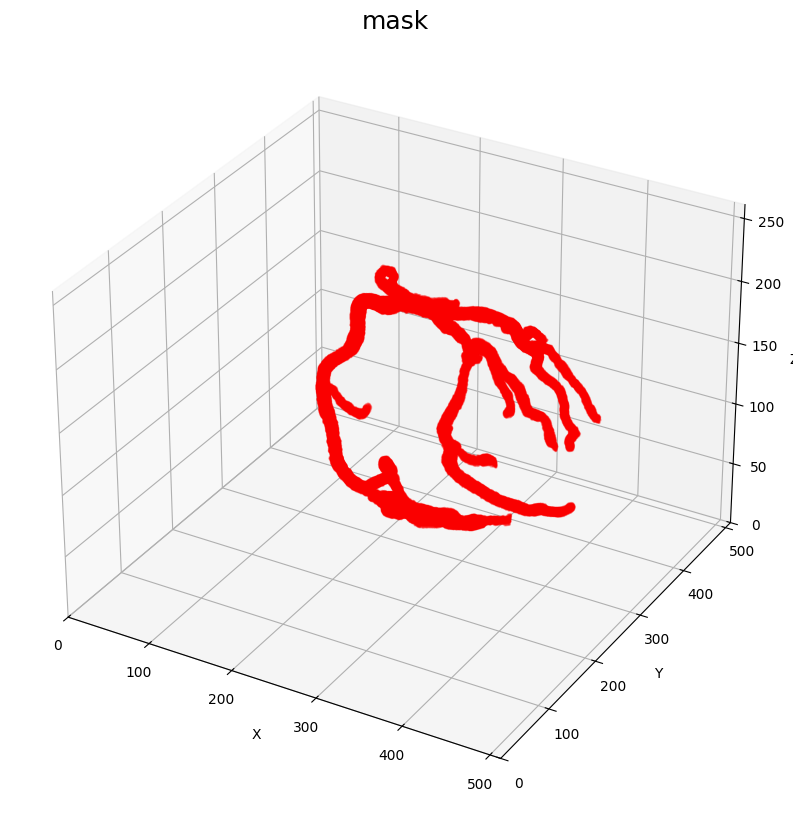

In [16]:
# Let's start with the mask
mask = nib.load(label_fp)
mask_matrice = mask.get_fdata()

visualize_3d_matrices(matrices=[mask_matrice], titles=["mask"])

In [17]:
# now the graph
with open(graph_fp, "r") as file:
    data = json.load(file)

pprint.pp(data["edges"])

[{'length': 45.555038631672225,
  'skeletons': [[-3.9306640625, 149.6103515625, -255.54998779296875],
                [-6.126192249041056, 149.9599770429464, -258.04998779296875],
                [-8.14768095468244, 151.59885282968244, -259.00876075463884],
                [-10.283266892278974, 153.416079392279, -259.6384502387676],
                [-12.042070778520191, 155.4932426535202, -260.30305196216773],
                [-13.879228167310293, 157.270957967176, -261.04998779296875],
                [-15.881907363569796, 158.8194203219174, -262.0133105071458],
                [-18.09720079118183, 159.92551012955806, -263.04998779296875],
                [-20.317997051971894, 160.76020554989023, -263.7871488071087],
                [-21.973209699622256, 162.24078782462226, -264.54998779296875],
                [-23.522207272858633, 163.79071705338518, -265.2775211090338],
                [-24.75324306631261, 165.97589931631262, -266.25293395846586],
                [-25.2983951599041

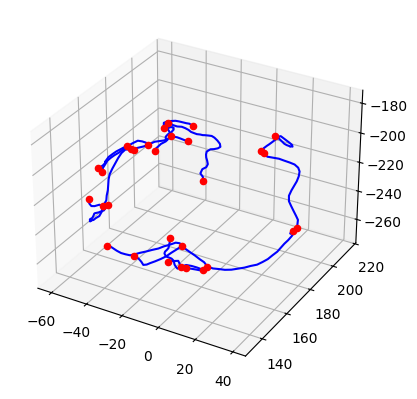

In [20]:
# Plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for node in data["nodes"]:
    [x, y, z] = node["pos"]
    ax.scatter(x, y, z, c="r")

for edge in data["edges"]:
    # length = edge["length"]
    # source = edge["source"]
    # target = edge["target"]

    skeletons = edge["skeletons"]
    xs, ys, zs = zip(*skeletons) # this is all we plot
    ax.plot(xs, ys, zs, c="b")

# get the np array from the plot
plt.show()